# Healthcare Dataset — Brief Summary

**Source:** Kaggle — *Healthcare Dataset* (synthetic; educational/non-commercial use)  
**Rows:** 10,000  
**Columns:** 15  
**File size:** ~8.4 MB  
**Granularity:** One row per synthetic patient healthcare record.

## Columns

| Column | Description / Notes |
|---|---|
| Name | Patient name; synthetic, inconsistent casing |
| Age | Patient age in years |
| Gender | Male / Female |
| Blood Type | A+, A-, B+, B-, AB+, AB-, O+, O- |
| Medical Condition | e.g., Arthritis, Diabetes, Cancer, Obesity, Hypertension, Asthma |
| Date of Admission | Admission date |
| Doctor | Doctor name |
| Hospital | Hospital name |
| Insurance Provider | e.g., Cigna, Medicare, Aetna, Blue Cross, UnitedHealthcare |
| Billing Amount | Numeric billing amount |
| Room Number | Integer room number |
| Admission Type | Elective, Urgent, Emergency |
| Discharge Date | Discharge date |
| Medication | e.g., Lipitor, Ibuprofen, Aspirin, Paracetamol, Penicillin |
| Test Results | Normal, Abnormal, Inconclusive |

## Key Distributions & Ranges

- **Gender:** 50% Male / 50% Female
- **Age:** approx. 13–89; most age bins contain ~2.4k–3.4k records, with sparse extremes
- **Blood Type:** A- 13%, A+ 13%, remaining blood types combined 75%
- **Medical Condition:** Arthritis 17%, Diabetes 17%, other conditions 66%
- **Admission Type:** Elective 34%, Urgent 33%, other 33% (includes Emergency)
- **Insurance Provider:** Cigna 20%, Medicare 20%, other providers 60%
- **Medication:** Lipitor 20%, Ibuprofen 20%, other medications 60%
- **Test Results:** Abnormal 34%, Normal 33%, other 33% (includes Inconclusive)
- **Admission Date Range:** 2019-05-08 to 2024-05-07
- **Discharge Date Range:** 2019-05-09 to 2024-06-06
- **Billing Amount Range:** approx. -2,008.49 to 52,764.28
- **Room Number Range:** 101–500; fairly uniform across bins

## Data Quality / Analysis Notes

- Dataset is **entirely synthetic** and contains no real patient data.
- High-cardinality text fields include **Name**, **Doctor**, and **Hospital**.
- Name casing is inconsistent in sample rows, e.g. `Bobby JacksOn`, `LesLie TErRy`.
- Billing Amount has a negative minimum; check whether this represents refunds, adjustments, or data noise.
- Several profiling charts collapse categories into **Other**; use raw data for complete category counts.
- Derived features possible:
  - Length of stay = `Discharge Date` - `Date of Admission`
  - Billing analysis by condition, insurance, admission type, or medication
  - Demographic and test-result breakdowns

In [1]:
import pandas as pd # import pandas
import numpy as np # import numpy
import matplotlib.pyplot as plt # import matplotlib
import seaborn as sns # import seaborn
import warnings # import warnings
warnings.filterwarnings('ignore') # ignore warnings


In [2]:
df = pd.read_csv('C:/Users/danie/Desktop/Portfolio/Tomisin-Analytics/BuildLabs_Internship[Nexus_Fellowship]/Task3/healthcare_dataset.csv') # read the csv file
df.head() # display the first 5 rows of the dataframe

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [3]:
# Initial Inspection of the dataset
print("Dataset Shape:", df.shape) # print the shape of the dataset
print("\nColumns in the dataset:") # print the columns in the dataset
print(df.columns.tolist())
print("\nData Types:") # print the data types of the columns
print(df.dtypes)


Dataset Shape: (55500, 15)

Columns in the dataset:
['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']

Data Types:
Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object


## Cleaning the Data

In [4]:
# 1. Missing Values: Check for missing values in the dataset and handle them appropriately (e.g., imputation, removal).
# Checking for missing values in the dataset
print("\nMissing Values (%) in the dataset:") # print the missing values in the dataset
print((df.isnull().sum() / len(df)) * 100)


Missing Values (%) in the dataset:
Name                  0.0
Age                   0.0
Gender                0.0
Blood Type            0.0
Medical Condition     0.0
Date of Admission     0.0
Doctor                0.0
Hospital              0.0
Insurance Provider    0.0
Billing Amount        0.0
Room Number           0.0
Admission Type        0.0
Discharge Date        0.0
Medication            0.0
Test Results          0.0
dtype: float64


In [5]:
# 2. Duplicate Rows: Check for duplicate rows in the dataset and remove them if necessary.
# Checking for duplicate rows in the dataset
print("\nDuplicate Rows in the dataset:") # print the duplicate rows in the dataset
print(df.duplicated().sum())


Duplicate Rows in the dataset:
534


In [6]:
# Dropping duplicate rows
df.drop_duplicates(inplace=True) # drop duplicate rows

# Checking for duplicate rows in the dataset
print(f"\nUpdated Duplicate Rows in the dataset: {df.duplicated().sum()}") # print the duplicate rows in the dataset



Updated Duplicate Rows in the dataset: 0


In [ ]:
# Check unique values in each column
for column in df.columns:
    unique_values = df[column].nunique() # Get the number of unique values in the column
    print(f"Column '{column}' has {unique_values} unique values.") # Print the number of unique values for each column  


In [7]:
df.head() # display the first 5 rows of the dataframe

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


Duplicates — they inflate counts and skew averages.
If the same record appears more than once, every summary statistic it touches is affected. Row counts and category frequencies grow larger than reality, while any mean, rate, or proportion gets pulled toward the duplicated values. Removing duplicates ensures your totals reflect the true number of unique cases.

In [8]:
# 3. Standardizing Text Columns: Standardize text columns by stripping whitespace and converting to proper case.
# Standardizing text columns (strip whitespace and convert to proper case)
text_cols = ['Name', 'Gender', 'Blood Type', 'Medical Condition', 'Doctor', 'Hospital', 
            'Insurance Provider', 'Admission Type', 'Medication', 'Test Results'] # select text columns
for col in text_cols:
    df[col] = df[col].str.strip().str.title() # strip whitespace and convert to proper case


df.head() # display the first 5 rows of the dataframe


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons And Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook Plc,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers And Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,Ab+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


Text standardization — prevents "Diabetes" and "diabetes" being counted separately.
The same condition or category can be written in many ways (case differences, whitespace, abbreviations, synonyms). Left uncorrected, each variant is treated as its own group, which fragments the categories, understates the true frequency of each, and creates confusing output. Normalizing text (e.g., lowercasing, trimming, mapping synonyms) merges these variants into one consistent label.

In [ ]:
# 4. Date Columns: Convert date columns to datetime format and extract relevant features (e.g., year, month, day).

print(f"\nInitial Data Types of 'Date of Admission' and 'Discharge Date' columns:")
print(df[['Date of Admission', 'Discharge Date']].dtypes)

# Converting dates
df['Date of Admission'] = pd.to_datetime(df['Date of Admission']) # convert Admission Date to datetime format
df['Discharge Date'] = pd.to_datetime(df['Discharge Date']) # convert Discharge Date to datetime format

print(f"\nFinal Data Types of 'Date of Admission' and 'Discharge Date' columns:")
print(df[['Date of Admission', 'Discharge Date']].dtypes) # display the data types of the date columns


Initial Data Types of 'Date of Admission' and 'Discharge Date' columns:
Date of Admission    object
Discharge Date       object
dtype: object

Final Data Types of 'Date of Admission' and 'Discharge Date' columns:
Date of Admission    datetime64[ns]
Discharge Date       datetime64[ns]
dtype: object


Date conversion — enables time-series analysis.
Dates stored as plain text can't be sorted, compared, or plotted over time. Converting them to a proper datetime type makes it possible to build timelines, compute durations, resample by day/month/quarter, and spot trends or seasonality.


In [ ]:
# 5. Negative Billing Amounts: Check for negative billing amounts and handle them appropriately (e.g., removal, correction).
df[df['Billing Amount'] < 0].shape # check for negative billing amounts

(106, 15)

In [14]:
df[df['Billing Amount'] < 0]

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
132,Ashley Erickson,32,Female,Ab-,Cancer,2019-11-05,Gerald Hooper,"And Johnson Moore, Branch",Aetna,-502.507813,376,Urgent,2019-11-23,Penicillin,Normal
799,Christopher Weiss,49,Female,Ab-,Asthma,2023-02-16,Kelly Thompson,Hunter-Hughes,Aetna,-1018.245371,204,Elective,2023-03-09,Penicillin,Inconclusive
1018,Ashley Warner,60,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"And Wagner, Lee Klein",Aetna,-306.364925,426,Elective,2022-01-11,Ibuprofen,Normal
1421,Jay Galloway,74,Female,O+,Asthma,2021-01-20,Debra Everett,Group Peters,Blue Cross,-109.097122,381,Emergency,2021-02-09,Ibuprofen,Abnormal
2103,Joshua Williamson,72,Female,B-,Diabetes,2021-03-21,Wendy Ramos,"And Huff Reeves, Dennis",Blue Cross,-576.727907,369,Urgent,2021-04-17,Aspirin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52213,Mr. Christopher Alvarado,74,Male,Ab+,Obesity,2022-06-03,Mr. Dean Guzman Dds,Johnson Inc,Blue Cross,-1310.272895,257,Elective,2022-06-13,Paracetamol,Inconclusive
52629,Gabrielle Decker,66,Male,Ab-,Arthritis,2022-11-07,William Krause,Diaz-Bishop,Cigna,-676.852502,354,Urgent,2022-11-30,Penicillin,Normal
53204,Ashley Warner,55,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"And Wagner, Lee Klein",Aetna,-306.364925,426,Elective,2022-01-11,Ibuprofen,Normal
53232,Daniel Drake,68,Female,B+,Hypertension,2020-04-24,Brett Ray,Carr Ltd,Aetna,-591.917419,426,Elective,2020-04-26,Lipitor,Abnormal


In [15]:
# Handling negative billing amounts by removing the rows with negative values
df = df[df['Billing Amount'] >= 0] # remove rows with negative billing amounts
df[df['Billing Amount'] < 0].shape # check for negative billing amounts

(0, 15)

Negative billing — often indicates errors or refunds, not valid charges.
A negative amount in a billing column usually reflects a refund, a reversal, or a data-entry mistake rather than a genuine charge. Treating these as valid positive values would distort revenue totals and any averages built on them, so they should be identified and handled deliberately.

In [16]:
# 6. Check for logical inconsistencies in the dataset (e.g., discharge date before admission date) and handle them appropriately.
invalid_rows = df[df['Discharge Date'] < df['Date of Admission']]
print(f"Invalid date records: {len(invalid_rows)}") # print the number of rows with discharge date before admission date

Invalid date records: 0


Date logic — discharge can't happen before admission.
Certain date relationships must hold by definition: a patient can't be discharged before they were admitted. Violations like this signal swapped fields, entry errors, or corrupted records. Checking these constraints catches problems that wouldn't be obvious from a single column alone.


## Featuring Engineering

In [23]:
# 1. Length of Stay: Calculate the length of stay for each patient and check for any negative or zero values.
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days # calculate the length of stay
print(df['Length of Stay'].describe()) # display the statistics of the length of stay column

count    54860.000000
mean        15.498815
std          8.661357
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length of Stay, dtype: float64


In [21]:
# 2. Age Categories: Create age categories (e.g., 0-18, 19-35, 36-50, 51-65, 66+) and check for any inconsistencies.
bins = [0, 18, 35, 50, 65, 100] # define the age bins
labels = ['0-18 (Pediatric)', '19-35 (Young Adult)', '36-50 (Adult)', '51-65 (Senior)', '66+ (Geriatric)'] # define the age category labels
df['Age Category'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False) # create the age categories
print(df['Age Category'].value_counts()) # display the count of each age category

Age Category
66+ (Geriatric)        16889
19-35 (Young Adult)    13458
51-65 (Senior)         12266
36-50 (Adult)          12131
0-18 (Pediatric)         116
Name: count, dtype: int64


In [24]:
# 3. Admission Month/Year (for trend analysis): Extract the month and year from the admission date and check for any seasonal trends.
df['Admission Month'] = df['Date of Admission'].dt.month_name() # extract the month from the admission date
df['Admission Year'] = df['Date of Admission'].dt.year # extract the year from the admission date
print(df['Admission Month'].value_counts()) # display the count of each admission month
df['Admission Year'].value_counts() # display the count of each admission year

Admission Month
August       4777
July         4762
January      4646
June         4640
March        4610
October      4605
December     4604
May          4547
September    4503
November     4501
April        4466
February     4199
Name: count, dtype: int64


Admission Year
2020    11157
2023    10918
2022    10891
2021    10795
2019     7280
2024     3819
Name: count, dtype: int64

In [25]:
# 4. Billing Categories
df['billing Category'] = pd.cut(df['Billing Amount'], 
                                bins=[0, 5000, 15000, 30000, float('inf')], 
                                labels=['Low', 'Medium', 'High', 'Very High']) # create billing categories
df['billing Category'].value_counts() # display the count of each billing category

billing Category
Very High    22460
High         16830
Medium       11169
Low           4401
Name: count, dtype: int64

In [26]:
# 5. Flag High Billing Cases (for predictive insights)
df['High Billing Flag'] = (df['Billing Amount'] > df['Billing Amount'].quantile(0.75)).astype(int) # flag high billing cases
print(df['High Billing Flag'].value_counts()) # display the count of each high billing flag

High Billing Flag
0    41145
1    13715
Name: count, dtype: int64


In [27]:
# 
print(" Feature Engineering completed successfully!")
print(f"New Shape: {df.shape}") # print the new shape of the dataset    

 Feature Engineering completed successfully!
New Shape: (54860, 21)


## Questions to answer

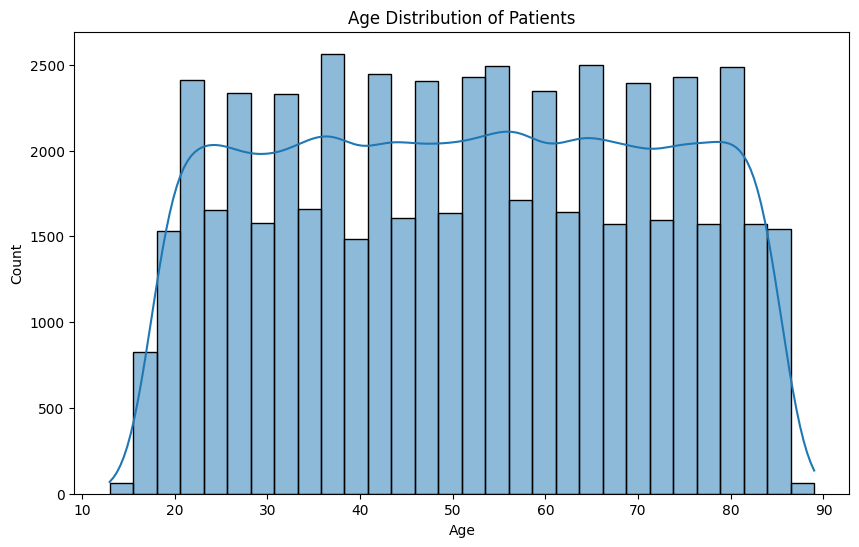

Gender
Male      27449
Female    27411
Name: count, dtype: int64


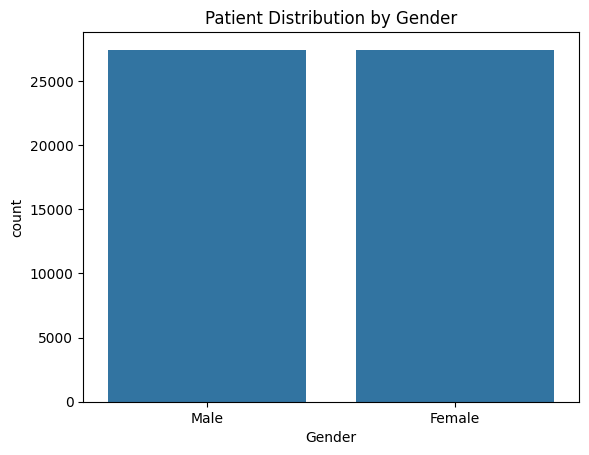

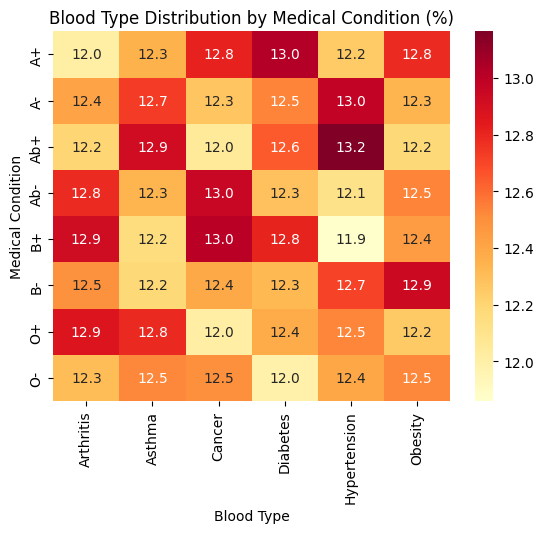

In [30]:
# Q1

# Age distribution
plt.figure(figsize=(10, 6)) # set the figure size
sns.histplot(df['Age'], bins=30, kde=True) # plot the age distribution
plt.title('Age Distribution of Patients') # set the title of the plot
plt.xlabel('Age') # set the x-axis label
plt.show() # display the plot


# GEnder distribution
print(df['Gender'].value_counts()) # display the count of each gender
sns.countplot(x='Gender', data=df) # plot the gender distribution
plt.title('Patient Distribution by Gender') # set the title of the plot
plt.xlabel('Gender') # set the x-axis label
plt.show() # display the plot


# Bloof Type vs conditions
blood_condition = pd.crosstab(df['Blood Type'], df['Medical Condition'], normalize='columns') * 100 # create a crosstab of blood type and medical condition
sns.heatmap(blood_condition, annot=True, fmt=".1f", cmap="YlOrRd") # plot the heatmap
plt.title('Blood Type Distribution by Medical Condition (%)') # set the title of the plot
plt.xlabel('Blood Type') # set the x-axis label
plt.ylabel('Medical Condition') # set the y-axis label
plt.show() # display the plot   

Medical Condition
Arthritis       9207
Diabetes        9197
Hypertension    9131
Obesity         9127
Cancer          9121
Asthma          9077
Name: count, dtype: int64


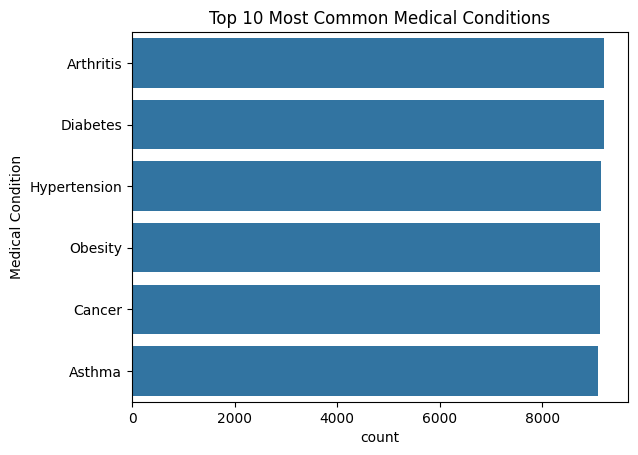

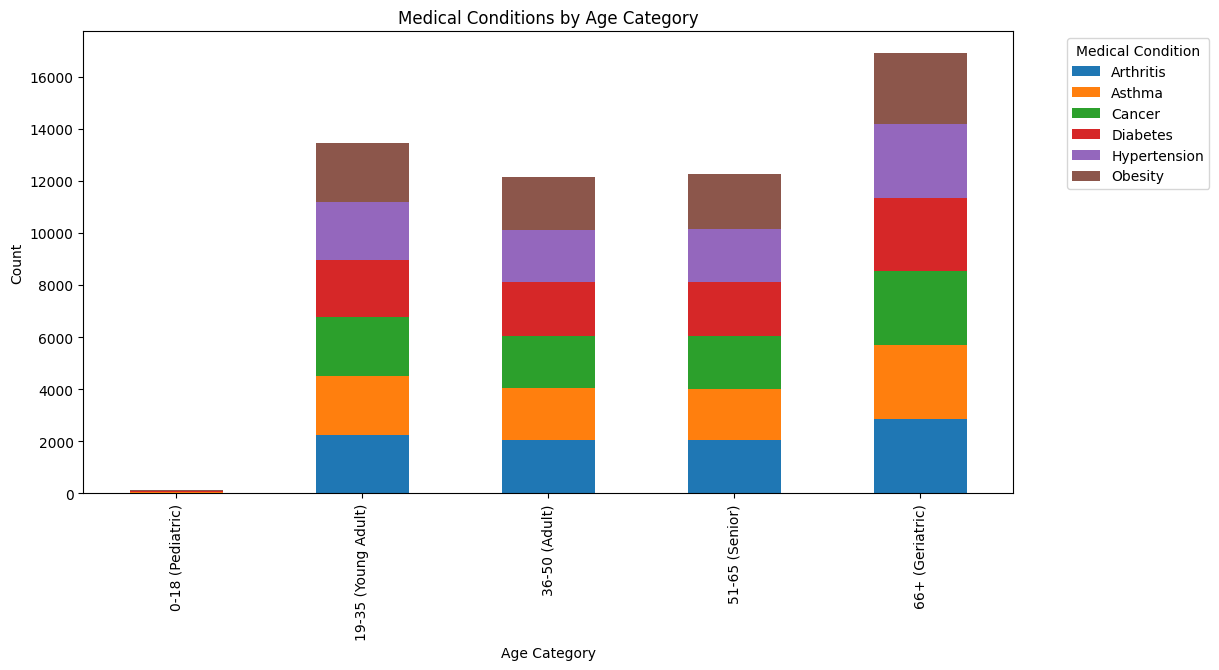

In [31]:
# Q2

# Most common medical conditions
print(df['Medical Condition'].value_counts()) # display the top 10 most common medical conditions
sns.countplot(data=df, y='Medical Condition', order=df['Medical Condition'].value_counts().index) # plot the top 10 most common medical conditions
plt.title('Top 10 Most Common Medical Conditions') # set the title of the plot
plt.show() # display the plot


# Conditions by Age group
age_condition = pd.crosstab(df['Age Category'], df['Medical Condition']) # create a crosstab of age category and medical condition
age_condition.plot(kind='bar', stacked=True, figsize=(12, 6)) # plot the stacked bar chart
plt.title('Medical Conditions by Age Category') # set the title of the plot
plt.xlabel('Age Category') # set the x-axis label
plt.ylabel('Count') # set the y-axis label
plt.legend(title='Medical Condition', bbox_to_anchor=(1.05, 1), loc='upper left') # set the legend
plt.show() # display the plot

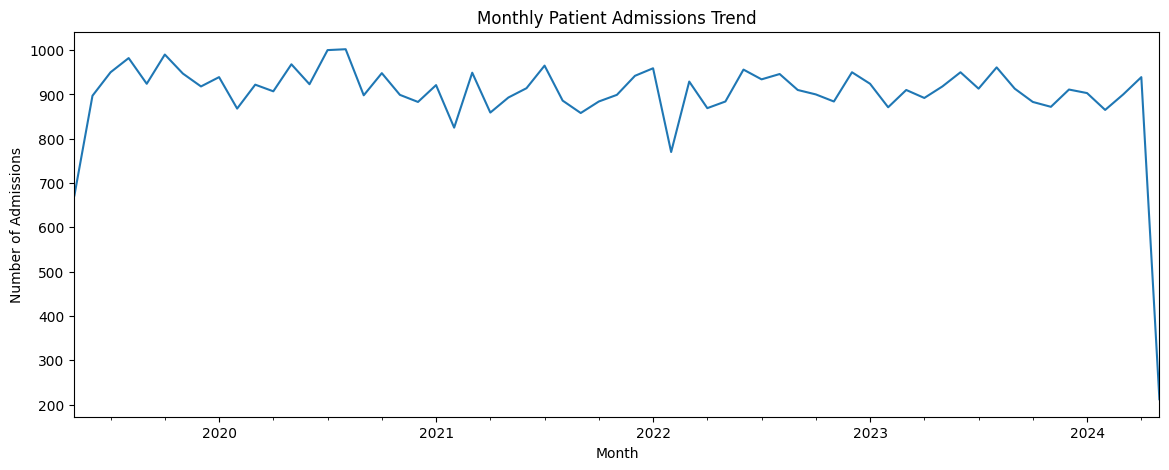

Admission Type
Elective     18437
Urgent       18353
Emergency    18070
Name: count, dtype: int64


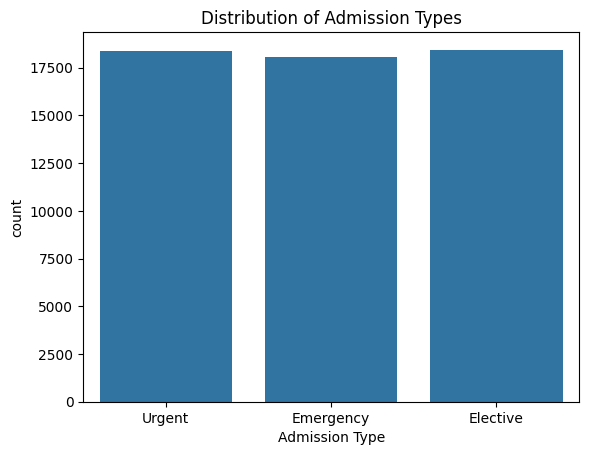

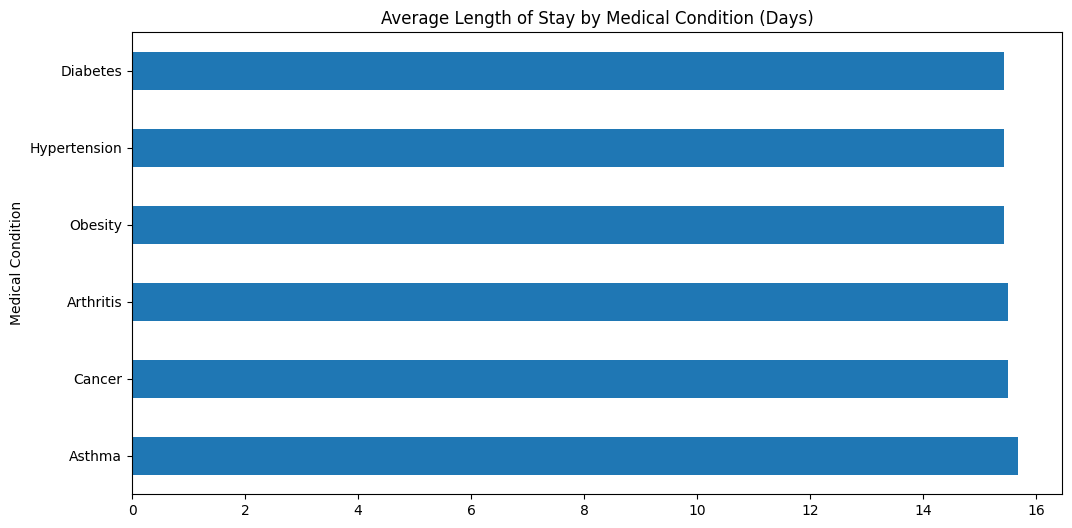

In [32]:
# Q3


# Admissions over time
monthly_admissions = df.groupby(pd.Grouper(key='Date of Admission', freq='M')).size() # group admissions by month
monthly_admissions.plot(figsize=(14, 5)) # plot the line chart
plt.title('Monthly Patient Admissions Trend') # set the title of the plot
plt.xlabel('Month') # set the x-axis label
plt.ylabel('Number of Admissions') # set the y-axis label
plt.show() # display the plot


# Admission type
print(df['Admission Type'].value_counts()) # display the count of each admission type
sns.countplot(x='Admission Type', data=df) # plot the admission type distribution
plt.title('Distribution of Admission Types') # set the title of the plot
plt.show() # display the plot


# Average length of stay by condition
los_by_condition = df.groupby('Medical Condition')['Length of Stay'].mean().sort_values(ascending=False) # calculate the average length of stay by medical condition
los_by_condition.plot(kind='barh', figsize=(12, 6)) # plot the bar chart
plt.title('Average Length of Stay by Medical Condition (Days)') # set the title of the plot
plt.show() # display the plot

                            sum          mean  count
Medical Condition                                   
Diabetes           2.364947e+08  25714.326349   9197
Obesity            2.360171e+08  25859.215373   9127
Arthritis          2.351735e+08  25542.898356   9207
Hypertension       2.333869e+08  25559.844868   9131
Asthma             2.331462e+08  25685.385020   9077
Cancer             2.299032e+08  25205.924207   9121
[Insurance Provider
Cigna               11115
Medicare            11018
Unitedhealthcare    10995
Blue Cross          10937
Aetna               10795
Name: count, dtype: int64]


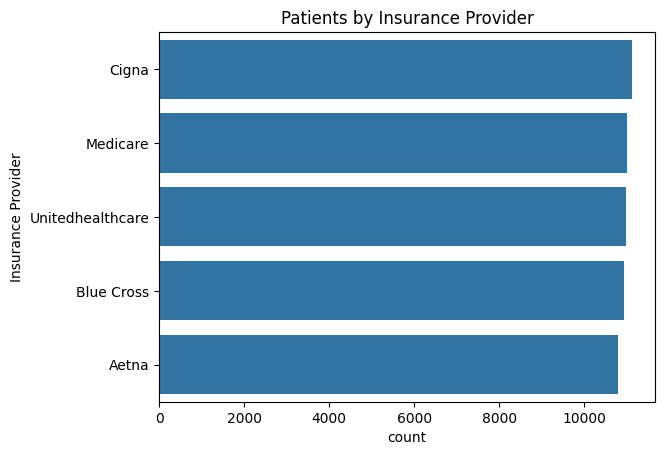

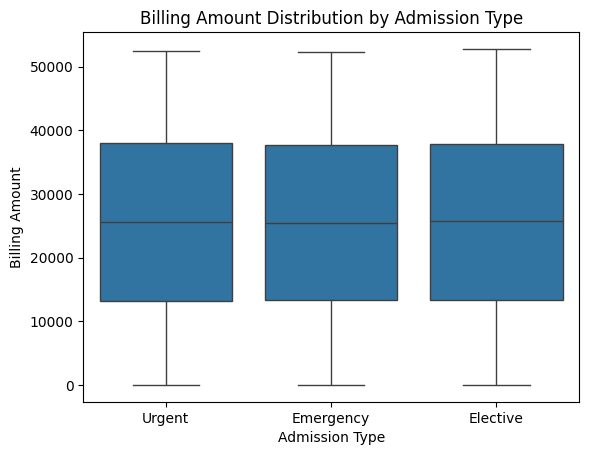

In [33]:
# Q4


# Billing by condition
billing_by_condition = df.groupby('Medical Condition')['Billing Amount'].agg(['sum', 'mean', 'count']) # calculate the total, average, and count of billing amount by medical condition
print(billing_by_condition.sort_values(by='sum', ascending=False)) # display the billing by condition sorted by total billing amount    


# Insurance providers
print([df['Insurance Provider'].value_counts()]) # display the count of each insurance provider
sns.countplot(data=df, y='Insurance Provider', order=df['Insurance Provider'].value_counts().index) # plot the insurance provider distribution
plt.title('Patients by Insurance Provider') # set the title of the plot
plt.show() # display the plot


# Admission type vs billing
sns.boxplot(x='Admission Type', y='Billing Amount', data=df) # plot the boxplot of billing amount by admission type
plt.title('Billing Amount Distribution by Admission Type') # set the title of the plot
plt.show() # display the plot


Hospital
Llc Smith                        44
Ltd Smith                        39
Johnson Plc                      37
Smith Ltd                        37
Smith Plc                        36
                                 ..
Buchanan Wheeler And Roberts,     1
Llc Conner                        1
Guzman Jones And Graves,          1
And Williams, Brown Mckenzie      1
And Garcia Morris Cunningham,     1
Name: count, Length: 39815, dtype: int64
Doctor
Michael Smith        27
John Smith           22
Robert Smith         21
Michael Johnson      20
David Smith          19
                     ..
Vanessa Newton        1
Donna Martinez Md     1
Stephanie Kramer      1
Angela Contreras      1
Wendy Glenn           1
Name: count, Length: 40276, dtype: int64


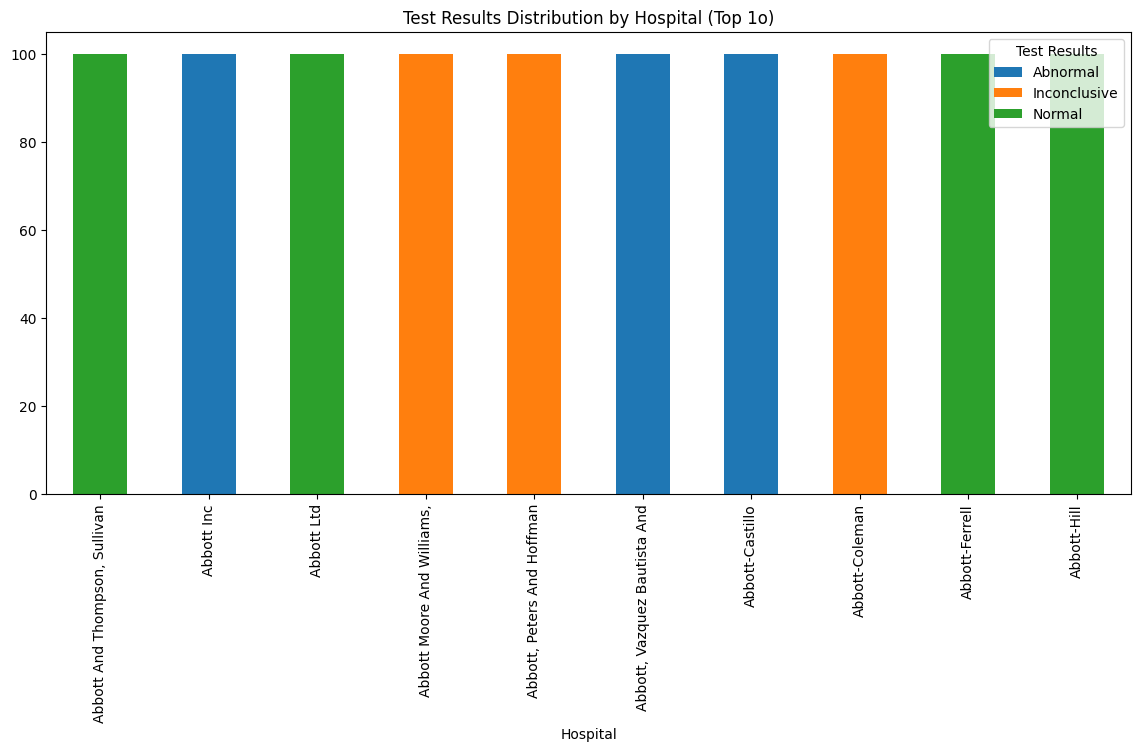

In [34]:
# Q5


# Hospitals with most cases
print(df['Hospital'].value_counts()) # display the count of each hospital


# Doctors with highest caseloads
print(df['Doctor'].value_counts()) # display the count of each doctor


# Outcomes by hospital
outcome_hospital = pd.crosstab(df['Hospital'], df['Test Results'], normalize='index') * 100 # create a crosstab of hospital and outcome
outcome_hospital.head(10). plot(kind='bar', stacked=True, figsize=(14, 6)) # plot the stacked bar chart
plt.title('Test Results Distribution by Hospital (Top 1o)') # set the title of the plot
plt.show() # display the plot


Test Results
Abnormal        18399
Normal          18302
Inconclusive    18159
Name: count, dtype: int64


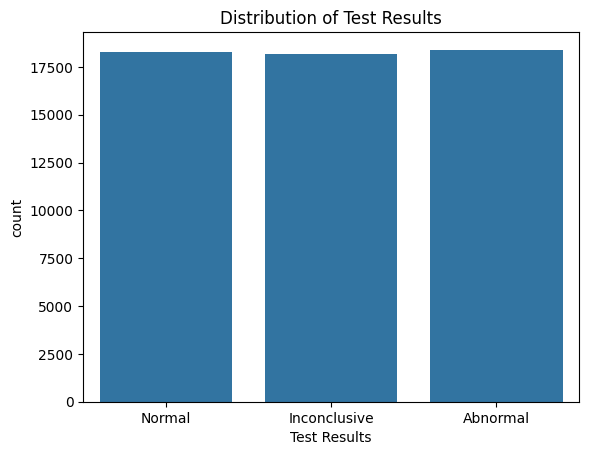

Recovery Rate (%) by Condition: 
Medical Condition
Asthma          34.295472
Hypertension    33.961231
Diabetes        33.260846
Obesity         33.143421
Cancer          33.011731
Arthritis       32.507874
Name: Test Results, dtype: float64


Medical Condition
Arthritis           Aspirin
Asthma          Paracetamol
Cancer              Lipitor
Diabetes            Lipitor
Hypertension      Ibuprofen
Obesity          Penicillin
dtype: object

In [37]:
# Q6


# Test results distribution
print(df['Test Results'].value_counts()) # display the count of each test result
sns.countplot(x='Test Results', data=df) # plot the test results distribution
plt.title('Distribution of Test Results') # set the title of the plot
plt.show() # display the plot


# Recovery rates by condition (Normal test results)
recovery_rate = df.groupby('Medical Condition')['Test Results'].apply(lambda x: (x == 'Normal').sum() / len(x) * 100).sort_values(ascending=False) # calculate the recovery rate by medical condition
print("Recovery Rate (%) by Condition: ")
print(recovery_rate) # display the recovery rate by medical condition


# Medications by condition
med_by_condition = df.groupby('Medical Condition')['Medication'].value_counts().unstack().fillna(0) # create a crosstab of medical condition and medication
med_by_condition.idxmax(axis=1) # find the most common medication for each medical condition


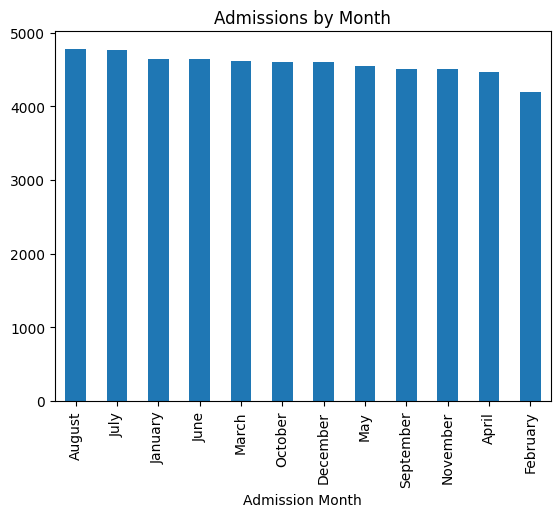

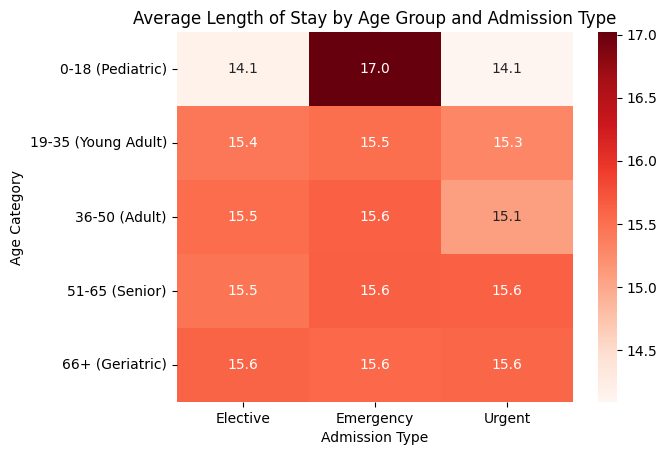

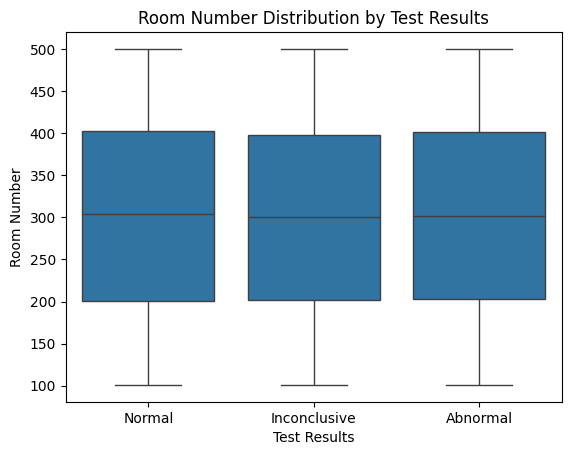

In [39]:
# Q7


# Peak admission periods (by month)
df['Admission Month'].value_counts().plot(kind='bar')
plt.title('Admissions by Month')
plt.show()


# Resource-intensive patient groups
resource_intensive = df.groupby(['Age Category', 'Admission Type'])['Length of Stay'].mean().unstack()
sns.heatmap(resource_intensive, annot=True, fmt='.1f', cmap='Reds')
plt.title('Average Length of Stay by Age Group and Admission Type')
plt.show()


# Room allocation patterns
sns.boxplot(data=df, x='Test Results', y='Room Number')
plt.title('Room Number Distribution by Test Results')
plt.show()


Trend: -1.3 admissions per month (R² = 0.046)


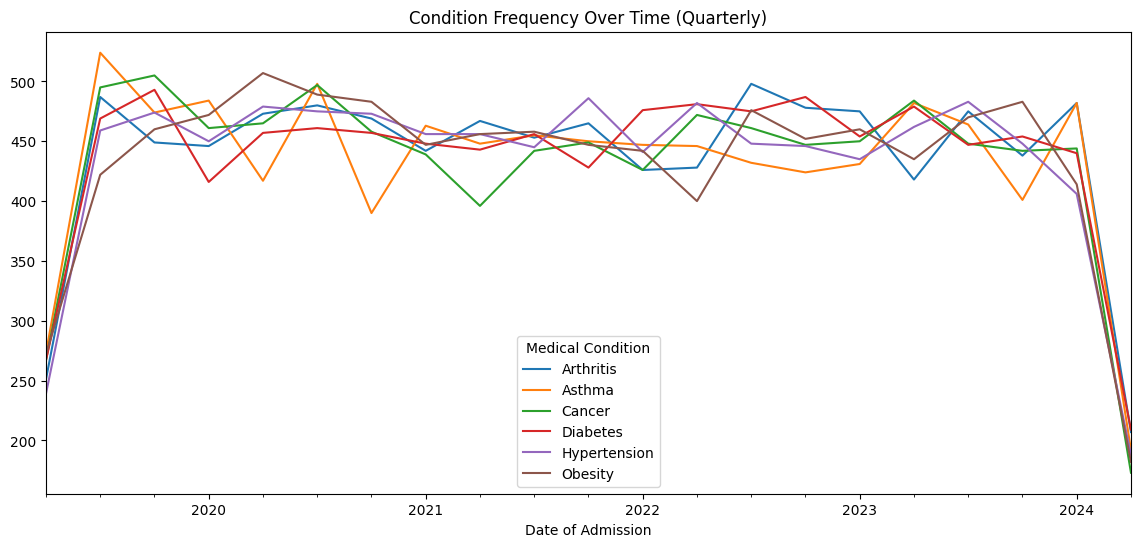

Patients with most admissions:
Name
Michael Williams    24
Michael Smith       23
Robert Smith        21
James Brown         19
James Smith         18
James Williams      16
John Johnson        16
John Smith          16
James Garcia        16
Kimberly Smith      16
dtype: int64
Model R² Score: 0.013

Top Predictors of High Billing:
                      Feature  Importance
0                         Age    0.260377
7              Length of Stay    0.201426
2          Blood Type_Encoded    0.122281
5  Insurance Provider_Encoded    0.103774
6          Medication_Encoded    0.103301
3   Medical Condition_Encoded    0.101416
4      Admission Type_Encoded    0.066124
1              Gender_Encoded    0.041302


In [40]:
# Q8


# 1. Projected admissions (simple moving average or linear trend)
from scipy import stats

monthly_counts = df.groupby(pd.Grouper(key='Date of Admission', freq='M')).size()
monthly_counts = monthly_counts.reset_index()
monthly_counts['Month_Num'] = range(len(monthly_counts))

slope, intercept, r_value, p_value, std_err = stats.linregress(
    monthly_counts['Month_Num'], monthly_counts[0]
)
print(f"Trend: {slope:.1f} admissions per month (R² = {r_value**2:.3f})")

# 2. Conditions likely to increase
condition_trend = df.groupby([pd.Grouper(key='Date of Admission', freq='Q'), 'Medical Condition']).size().unstack()
condition_trend.plot(figsize=(14, 6))
plt.title('Condition Frequency Over Time (Quarterly)')
plt.show()

# 3. High-risk demographics for frequent admission
frequent_admitters = df.groupby('Name').size().sort_values(ascending=False)
print("Patients with most admissions:")
print(frequent_admitters.head(10))

# 4. Predictors of high billing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Prepare features
le = LabelEncoder()
df_ml = df.copy()
for col in ['Gender', 'Blood Type', 'Medical Condition', 'Admission Type', 
            'Insurance Provider', 'Medication', 'Test Results']:
    df_ml[col + '_Encoded'] = le.fit_transform(df_ml[col].astype(str))

features = ['Age', 'Gender_Encoded', 'Blood Type_Encoded', 'Medical Condition_Encoded',
            'Admission Type_Encoded', 'Insurance Provider_Encoded', 'Medication_Encoded',
            'Length of Stay']
X = df_ml[features]
y = df_ml['Billing Amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print(f"Model R² Score: {model.score(X_test, y_test):.3f}")

# Feature importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nTop Predictors of High Billing:")
print(importance)

## Export Data for Power BI

In [41]:

# Export cleaned data for Power BI
df.to_csv('healthcare_clean_data.csv', index=False)


# Create aggregated tables for performance
# Monthly admissions
monthly_agg = df.groupby(pd.Grouper(key='Date of Admission', freq='M')).agg({
    'Name': 'count',
    'Billing Amount': 'sum',
    'Length of Stay': 'mean'
}).reset_index()
monthly_agg.columns = ['Month', 'Admissions', 'Total_Billing', 'Avg_Length_of_Stay']
monthly_agg.to_csv('monthly_agg.csv', index=False)


# Condition summary
condition_agg = df.groupby('Medical Condition').agg({
    'Name': 'count',
    'Billing Amount': ['sum', 'mean'],
    'Length of Stay': 'mean'
}).reset_index()
condition_agg.columns = ['Condition', 'Patient_Count', 'Total_Billing', 'Avg_Billing', 'Avg_LOS']
condition_agg.to_csv('condition_agg.csv', index=False)

print("✅ Files exported for Power BI!")

✅ Files exported for Power BI!
